In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [3]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

latent_df_base = pd.read_parquet(DATA_LATENT / "fc_vae_latents.parquet")
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

latent_df_base["date"] = pd.to_datetime(latent_df_base["date"])
returns.index = pd.to_datetime(returns.index)

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

z_cols = [c for c in latent_df_base.columns if c.startswith("z_")]

In [4]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    })

In [5]:
def make_future_returns(returns, horizon):
    future = pd.DataFrame(
        0.0,
        index=returns.index,
        columns=returns.columns
    )

    for h in range(1, horizon + 1):
        future += returns.shift(-h)

    return future

In [6]:
def attach_target_return(latent_df, future_returns, target_col):
    rows = []

    for _, row in latent_df[["date", "ticker"]].iterrows():
        date = row["date"]
        ticker = row["ticker"]

        try:
            rows.append(future_returns.loc[date, ticker])
        except KeyError:
            rows.append(np.nan)

    latent_df[target_col] = rows
    return latent_df.dropna(subset=[target_col]).copy()

In [7]:
def fit_ridge_scores(latent_df_base, returns, horizon, train_ratio=0.7):
    latent_df = latent_df_base.copy()

    target_col = f"target_return_{horizon}d"
    future_returns = make_future_returns(returns, horizon)

    latent_df = attach_target_return(
        latent_df,
        future_returns,
        target_col=target_col
    )

    dates = np.sort(latent_df["date"].unique())
    split_date = dates[int(train_ratio * len(dates))]

    train_mask = latent_df["date"] < split_date
    test_mask = latent_df["date"] >= split_date

    X_train = latent_df.loc[train_mask, z_cols].values
    y_train = latent_df.loc[train_mask, target_col].values

    X_test = latent_df.loc[test_mask, z_cols].values
    y_test = latent_df.loc[test_mask, target_col].values

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    latent_df["score"] = model.predict(latent_df[z_cols].values)

    diagnostics = {
        "horizon": horizon,
        "split_date": split_date,
        "train_corr": np.corrcoef(y_train, y_pred_train)[0, 1],
        "test_corr": np.corrcoef(y_test, y_pred_test)[0, 1],
        "test_mse": mean_squared_error(y_test, y_pred_test),
    }

    return latent_df, diagnostics

In [8]:
def build_rebalanced_positions(
    scored_df,
    returns,
    split_date,
    rebalance_every=5,
    long_q=0.8,
    short_q=0.2
):
    test_dates = np.array(
        sorted(scored_df.loc[scored_df["date"] >= split_date, "date"].unique())
    )

    tickers = sorted(scored_df["ticker"].unique())

    positions = pd.DataFrame(
        0,
        index=test_dates,
        columns=tickers,
        dtype=float
    )

    current_position = pd.Series(0.0, index=tickers)

    for i, date in enumerate(test_dates):
        if i % rebalance_every == 0:
            g = scored_df[scored_df["date"] == date].copy()

            scores = g.set_index("ticker")["score"].dropna()

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(0.0, index=tickers)
            new_position.loc[scores[scores >= long_threshold].index] = 1.0
            new_position.loc[scores[scores <= short_threshold].index] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [9]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    costs = transaction_cost * turnover

    net = gross - costs

    return net, turnover

In [10]:
def run_rebalance_experiment(
    latent_df_base,
    returns,
    horizon,
    rebalance_every,
    transaction_cost=0.0
):
    scored_df, diagnostics = fit_ridge_scores(
        latent_df_base,
        returns,
        horizon=horizon,
        train_ratio=0.7
    )

    positions = build_rebalanced_positions(
        scored_df=scored_df,
        returns=returns,
        split_date=diagnostics["split_date"],
        rebalance_every=rebalance_every,
        long_q=0.8,
        short_q=0.2
    )

    portfolio_returns, turnover = portfolio_returns_from_positions(
        positions,
        returns,
        transaction_cost=transaction_cost
    )

    stats = performance_stats(portfolio_returns)

    result = {
        "horizon": horizon,
        "rebalance_every": rebalance_every,
        **diagnostics,
        **stats.to_dict(),
        "avg_turnover": turnover.mean(),
    }

    return result, portfolio_returns, turnover, positions

In [11]:
HORIZONS = [1, 5, 10, 20]
REBALANCES = [1, 5, 10, 20]

results = []
returns_dict = {}

for horizon in HORIZONS:
    for rebalance_every in REBALANCES:
        print(f"horizon={horizon}, rebalance={rebalance_every}")

        result, port_ret, turnover, positions = run_rebalance_experiment(
            latent_df_base=latent_df_base,
            returns=returns,
            horizon=horizon,
            rebalance_every=rebalance_every,
            transaction_cost=0.0
        )

        key = f"h{horizon}_reb{rebalance_every}"

        results.append(result)
        returns_dict[key] = port_ret

horizon=1, rebalance=1


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

horizon=1, rebalance=5


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

horizon=1, rebalance=10


...

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

horizon=20, rebalance=10


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

horizon=20, rebalance=20


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

In [12]:
results_df = pd.DataFrame(results)

results_df.sort_values("sharpe", ascending=False)

,horizon,rebalance_every,split_date,train_corr,test_corr,test_mse,total_return,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover
10,10,10,2022-03-09,0.132415,0.055081,0.004452,0.128069,0.044467,0.063691,0.698173,-0.103065,0.018529
0,1,1,2022-03-17,0.039953,0.015071,0.000439,0.126959,0.043903,0.063699,0.689230,-0.107570,0.024631
12,20,1,2022-02-28,0.183128,0.073004,0.008917,0.119814,0.041885,0.066363,0.631145,-0.107684,0.028585
4,5,1,2022-03-14,0.092709,0.037858,0.002215,0.116715,0.040541,0.064496,0.628590,-0.115944,0.027429
7,5,20,2022-03-14,0.092709,0.037858,0.002215,0.111834,0.038902,0.064345,0.604582,-0.099479,0.014286
6,5,10,2022-03-14,0.092709,0.037858,0.002215,0.109964,0.038272,0.063838,0.599525,-0.115055,0.017619
8,10,1,2022-03-09,0.132415,0.055081,0.004452,0.102861,0.035980,0.064616,0.556826,-0.118719,0.027985
11,10,20,2022-03-09,0.132415,0.055081,0.004452,0.101615,0.035557,0.063879,0.556627,-0.111855,0.014422
1,1,5,2022-03-17,0.039953,0.015071,0.000439,0.100335,0.034970,0.063714,0.548856,-0.101641,0.019591
5,5,5,2022-03-14,0.092709,0.037858,0.002215,0.099322,0.034677,0.063692,0.544457,-0.117407,0.020476


In [13]:
sharpe_table = results_df.pivot(
    index="horizon",
    columns="rebalance_every",
    values="sharpe"
)

sharpe_table

rebalance_every,1,5,10,20
horizon,,,,
1,0.689230,0.548856,0.408597,0.495965
5,0.628590,0.544457,0.599525,0.604582
10,0.556826,0.537005,0.698173,0.556627
20,0.631145,0.518069,0.400641,0.430471


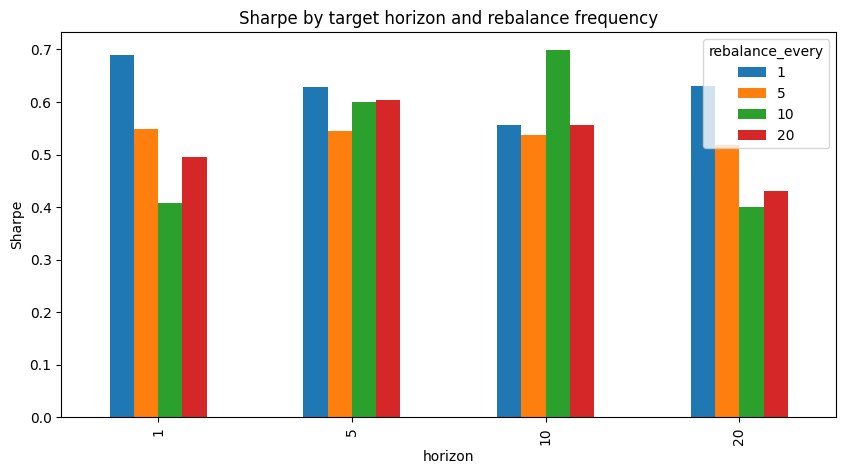

In [14]:
sharpe_table.plot(
    kind="bar",
    figsize=(10, 5),
    title="Sharpe by target horizon and rebalance frequency"
)

plt.ylabel("Sharpe")
plt.show()

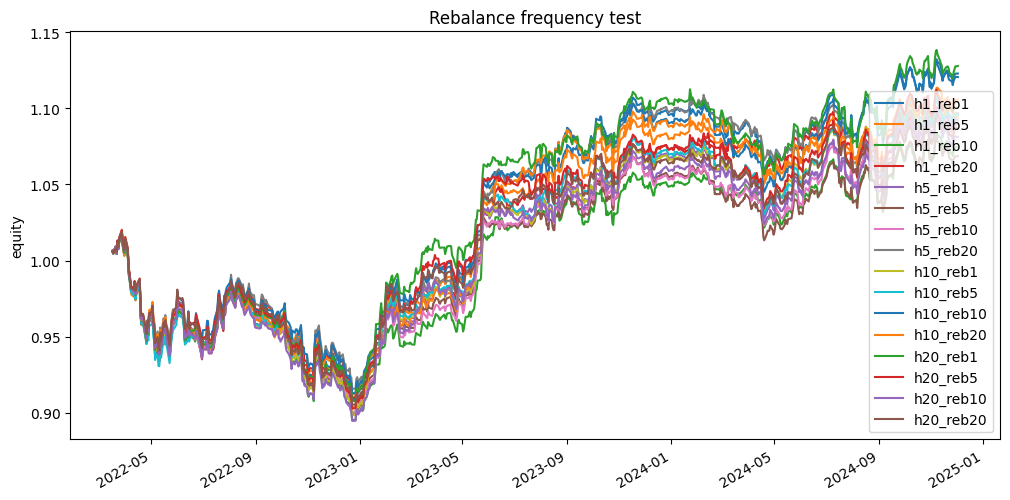

In [15]:
returns_comparison = pd.concat(returns_dict, axis=1).dropna()

equity = (1 + returns_comparison).cumprod()

equity.plot(
    figsize=(12, 6),
    title="Rebalance frequency test"
)

plt.ylabel("equity")
plt.show()

In [16]:
results_df.to_csv(
    DATA_BACKTESTS / "vae_ridge_rebalance_sweep_results.csv",
    index=False
)

returns_comparison.to_parquet(
    DATA_BACKTESTS / "vae_ridge_rebalance_sweep_returns.parquet"
)

In [17]:
results_df.sort_values("sharpe", ascending=False)

,horizon,rebalance_every,split_date,train_corr,test_corr,test_mse,total_return,ann_return,ann_vol,sharpe,max_drawdown,avg_turnover
10,10,10,2022-03-09,0.132415,0.055081,0.004452,0.128069,0.044467,0.063691,0.698173,-0.103065,0.018529
0,1,1,2022-03-17,0.039953,0.015071,0.000439,0.126959,0.043903,0.063699,0.689230,-0.107570,0.024631
12,20,1,2022-02-28,0.183128,0.073004,0.008917,0.119814,0.041885,0.066363,0.631145,-0.107684,0.028585
4,5,1,2022-03-14,0.092709,0.037858,0.002215,0.116715,0.040541,0.064496,0.628590,-0.115944,0.027429
7,5,20,2022-03-14,0.092709,0.037858,0.002215,0.111834,0.038902,0.064345,0.604582,-0.099479,0.014286
6,5,10,2022-03-14,0.092709,0.037858,0.002215,0.109964,0.038272,0.063838,0.599525,-0.115055,0.017619
8,10,1,2022-03-09,0.132415,0.055081,0.004452,0.102861,0.035980,0.064616,0.556826,-0.118719,0.027985
11,10,20,2022-03-09,0.132415,0.055081,0.004452,0.101615,0.035557,0.063879,0.556627,-0.111855,0.014422
1,1,5,2022-03-17,0.039953,0.015071,0.000439,0.100335,0.034970,0.063714,0.548856,-0.101641,0.019591
5,5,5,2022-03-14,0.092709,0.037858,0.002215,0.099322,0.034677,0.063692,0.544457,-0.117407,0.020476
